### Uses R v4.3.3.

### Uncomment to install BiocManager and DESeq2.  Comment back out after running once.  It's not necessary to reinstall every time the notebook is ran.

In [1]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")
# BiocManager::install(version = "3.18")
# BiocManager::install(c("edgeR"))

### Uncomment out each package individually and run the cell to install each package.  Do this one at a time and watch the terminal output to see if any additional dependencies need to be installed on your system.  This is espeically true on Linux where you need to install other packages from the package manager.

In [2]:
# install.packages('readr', version='2.1.5')
# install.packages('dplyr', version='1.1.4')
# install.packages('plotly', version='4.10.4')

In [3]:
library(readr)
library(dplyr)

library(edgeR)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: limma



# Differential expression analysis of RNA-seq Data using edgeR: A comparative study of the Vlasov dataset reflecting survivors versus fatal cases. Both groups had severe acute COVID-19.

### Introduction:
This analysis focuses on the DEGs analysis of two categories from one dataset, Vlasov Et al that was uniformly processed along with other datasets using the Bwb software, and the edgeR package set to FDR < 0.05 and a log2foldchange = 1.25.  The input sample sheet intergrates metadata and filters the gene expression data acoordingly. The overall aim is to identify key genes that reflect significant expression differences between the two groups of participants (survivors versus fatal cases secondary to severe active COVID-19). The diagram below shows this comparison as pathway (v) reflecting a sample set from Russia (Group I).

### Specific Objectives
1. **Data Processing** - Importing and cleaning the metadata
2. **Filtering out Low Expression Genes** - Dropping genes with low expression to improve statistical power
3. **Normalization** - Using Trimmed Mean of M-values to adjust for differences in sequencing depth
4. **Differential expression analysis** - Using a negative binomial exact test (see here for the packge documentation)
5. **Extract and interpret top DEGs** - to highlight their biological relevance
6. **Set-up for downstream GSEA** - use the outputs to create rank lists for GSEA (different notebook)

![Study design](./images/Study_design.png)

### Data Processing - Importing and cleaning the metadata

In this section, we import the normalized counts matrix from Bwb's uniform processing as our input for the Vlas Et al.  We will later filter it to keep only the relevant samples using our sample sheet created using a different notebook.

The input file is cleaned by removing suffixes from the column headers to allow for congruence with other datasets that we will concatenate with.  We will sort the columns for consistency and then perform a sanity check by display the head to show only afew rows of the output.

## Change the Vlasov Gene Counts location by updating the read.csv() value.

In [4]:
# Read Yin counts
vlasov.counts <- as.matrix(read.csv("./data/Vlasov/genesCounts.csv", sep="\t",row.names="Name"))

# Edit sample names in dataframe
colnames(vlasov.counts) <- sapply(strsplit(colnames(vlasov.counts), "_"), `[`, 1)

# Order the dataframe by column name
vlasov.counts <- vlasov.counts[, sort(colnames(vlasov.counts))]

head(vlasov.counts)

,SRR16317814,SRR16317815,SRR16317816,SRR16317817,SRR16317818,SRR16317819,SRR16317820,SRR16317821,SRR16317822,SRR16317823,SRR16317824,SRR16317825,SRR16317826,SRR16317827,SRR16317828,SRR16317829
ENSG00000268674,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000271254,70,84,57,50,31,28,42,31,85,72,68,62,94,105,64,89
ENSG00000275063,148,118,415,474,121,99,11,12,117,129,15,29,164,221,507,530
ENSG00000277856,101,78,173,168,48,54,9,24,76,81,15,26,109,136,325,361
ENSG00000276345,185,151,127,120,85,83,127,34,41,98,0,0,121,100,202,191
ENSG00000278633,5,13,8,3,4,2,10,3,13,10,15,12,4,5,13,2


We also want to see the dimensions of our normalized count matrix.  In this case, we have 38,592 genes in the rows and 152 samples in columns all together.

In [5]:
# Sanity check
dim(vlasov.counts)

[1] 38592    16

## Change the Compendium metadata locations by updating the read_tsv() values.

In [6]:
# Read Andrew's Compendium data: Group H - Vlasov
vlasov.metadata.h = read.csv("./Andrews_Compendium/output/vlasov_sample_sheet_covid_h.csv")

vlasov.metadata.h

Run,age,Assay.Type,AvgSpotLen,Bases,batch,BioProject,BioSample,Bytes,Center.Name,⋯,rin,rna_extraction_time,create_date,version,sample_extraction_time,Sample.Name,source_name,SRA.Study,survival_status,tissue
<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,⋯,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR16317816,79,RNA-Seq,50,628696450,Batch 1,PRJNA771040,SAMN22249190,288277508,GEO,⋯,9.2,2020-07-12T13:00:00Z,2021-10-13T15:53:00Z,1,07.12.2020 6:00,GSM5624885,blood of patient with COVID-19 114 – replication 1,SRP341246,survived,blood
SRR16317817,79,RNA-Seq,50,634761750,Batch 1,PRJNA771040,SAMN22249192,291102651,GEO,⋯,9.2,2020-07-12T13:00:00Z,2021-10-13T15:54:00Z,1,07.12.2020 6:00,GSM5624886,blood of patient with COVID-19 114 – replication 2,SRP341246,survived,blood
SRR16317818,74,RNA-Seq,50,563743800,Batch 1,PRJNA771040,SAMN22249193,258757934,GEO,⋯,8.8,2020-12-09T13:20:00Z,2021-10-13T15:52:00Z,1,12/8/2020 17:00,GSM5624887,blood of patient with COVID-19 126 – replication 1,SRP341246,survived,blood
SRR16317819,74,RNA-Seq,50,598788600,Batch 1,PRJNA771040,SAMN22249194,274689760,GEO,⋯,8.8,2020-12-09T13:20:00Z,2021-10-13T15:52:00Z,1,12/8/2020 17:00,GSM5624888,blood of patient with COVID-19 126 – replication 2,SRP341246,survived,blood
SRR16317822,72,RNA-Seq,50,614993050,Batch 1,PRJNA771040,SAMN22249197,281985244,GEO,⋯,7.5,2020-11-21T13:20:00Z,2021-10-13T15:53:00Z,1,11/20/2020 17:00,GSM5624891,blood of patient with COVID-19 51 – replication 1,SRP341246,survived,blood
SRR16317823,72,RNA-Seq,50,641257450,Batch 1,PRJNA771040,SAMN22249198,294617577,GEO,⋯,7.5,2020-11-21T13:20:00Z,2021-10-13T15:53:00Z,1,11/20/2020 17:00,GSM5624892,blood of patient with COVID-19 51 – replication 2,SRP341246,survived,blood
SRR16317824,59,RNA-Seq,50,582362500,Batch 1,PRJNA771040,SAMN22249199,267232855,GEO,⋯,9.2,2020-12-02T00:00:00Z,2021-10-13T15:53:00Z,1,,GSM5624893,blood of patient with COVID-19 96 – replication 1,SRP341246,survived,blood
SRR16317825,59,RNA-Seq,50,612843900,Batch 1,PRJNA771040,SAMN22249200,280920183,GEO,⋯,9.2,2020-12-02T00:00:00Z,2021-10-13T15:52:00Z,1,,GSM5624894,blood of patient with COVID-19 96 – replication 2,SRP341246,survived,blood
SRR16317828,63,RNA-Seq,50,561074100,Batch 1,PRJNA771040,SAMN22249204,257577161,GEO,⋯,9.6,2020-12-03T11:00:00Z,2021-10-13T15:52:00Z,1,12/2/2020 19:30,GSM5624897,blood of patient with COVID-19 99 – replication 1,SRP341246,survived,blood


In [7]:
# Reduce and convert vlasov.metadata.h into sheet that can be concatenated
vlasov.metadata.h.reduced = vlasov.metadata.h[c("Run", "survival_status")]
colnames(vlasov.metadata.h.reduced)[2] <- "disease_severity"
                                            
vlasov.metadata.h.reduced 

Run,disease_severity
<chr>,<chr>
SRR16317816,survived
SRR16317817,survived
SRR16317818,survived
SRR16317819,survived
SRR16317822,survived
SRR16317823,survived
SRR16317824,survived
SRR16317825,survived
SRR16317828,survived


### Loading the metadata

Now that we have the normalized data with counts matrix from Vlasov, we need the metadata which will guide us in 
subsetting our data with respect to clinical attributes like presence or healthy, fatal cases, and survivors of severe acute COVID-19. We include the sample sheets for our desired comparisons which are those that survived and the deceased secondary to severe acute COVID-19.

We also prepare the metadata dataset by removing the extra index column, combining all relevant sample sheets for inclusion, then sorting by sample name "Run".

## Change the Compendium metadata locations by updating the read_tsv() values.

In [8]:
# Read Andrew's Compendium data: Group I - Vlasov
vlasov.metadata.i = read.csv("./Andrews_Compendium/output/vlasov_sample_sheet_covid_i.csv")

vlasov.metadata.i

Run,age,Assay.Type,AvgSpotLen,Bases,batch,BioProject,BioSample,Bytes,Center.Name,⋯,rin,rna_extraction_time,create_date,version,sample_extraction_time,Sample.Name,source_name,SRA.Study,survival_status,tissue
<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,⋯,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR16317814,63,RNA-Seq,50,601066000,Batch 1,PRJNA771040,SAMN22249188,275643425,GEO,⋯,NA,2020-12-03T11:00:00Z,2021-10-13T15:53:00Z,1,12/2/2020 18:00,GSM5624883,blood of patient with COVID-19 101 – replication 1,SRP341246,deceased,blood
SRR16317815,63,RNA-Seq,50,562428800,Batch 1,PRJNA771040,SAMN22249189,258643662,GEO,⋯,NA,2020-12-03T11:00:00Z,2021-10-13T15:52:00Z,1,12/2/2020 18:00,GSM5624884,blood of patient with COVID-19 101 – replication 2,SRP341246,deceased,blood
SRR16317820,66,RNA-Seq,50,613339850,Batch 1,PRJNA771040,SAMN22249195,281566156,GEO,⋯,9.4,2020-11-17T14:40:00Z,2021-10-13T15:53:00Z,1,11/16/2020 19:30,GSM5624889,blood of patient with COVID-19 38 – replication 1,SRP341246,deceased,blood
SRR16317821,66,RNA-Seq,50,638412700,Batch 1,PRJNA771040,SAMN22249196,292367728,GEO,⋯,9.4,2020-11-17T14:40:00Z,2021-10-13T15:53:00Z,1,11/16/2020 19:30,GSM5624890,blood of patient with COVID-19 38 – replication 2,SRP341246,deceased,blood
SRR16317826,72,RNA-Seq,50,546528950,Batch 1,PRJNA771040,SAMN22249202,250987146,GEO,⋯,9.8,2020-12-02T00:00:00Z,2021-10-13T15:51:00Z,1,12/2/2020,GSM5624895,blood of patient with COVID-19 98 – replication 1,SRP341246,deceased,blood
SRR16317827,72,RNA-Seq,50,645548350,Batch 1,PRJNA771040,SAMN22249203,296014354,GEO,⋯,9.8,2020-12-02T00:00:00Z,2021-10-13T15:53:00Z,1,12/2/2020,GSM5624896,blood of patient with COVID-19 98 – replication 2,SRP341246,deceased,blood


In [9]:
# Reduce and convert vlasov.metadata.i into sheet that can be concatenated
vlasov.metadata.i.reduced = vlasov.metadata.i[c("Run", "survival_status")]
colnames(vlasov.metadata.i.reduced)[2] <- "disease_severity"
                                            
vlasov.metadata.i.reduced             

Run,disease_severity
<chr>,<chr>
SRR16317814,deceased
SRR16317815,deceased
SRR16317820,deceased
SRR16317821,deceased
SRR16317826,deceased
SRR16317827,deceased


In [10]:
# Create dataframe from Gene Counts that only contains samples from compendium
vlasov.h.counts.of.interest <- vlasov.counts[, vlasov.metadata.h$Run]

head(vlasov.h.counts.of.interest)

,SRR16317816,SRR16317817,SRR16317818,SRR16317819,SRR16317822,SRR16317823,SRR16317824,SRR16317825,SRR16317828,SRR16317829
ENSG00000268674,0,0,0,0,0,0,0,0,0,0
ENSG00000271254,57,50,31,28,85,72,68,62,64,89
ENSG00000275063,415,474,121,99,117,129,15,29,507,530
ENSG00000277856,173,168,48,54,76,81,15,26,325,361
ENSG00000276345,127,120,85,83,41,98,0,0,202,191
ENSG00000278633,8,3,4,2,13,10,15,12,13,2


In [11]:
# Create dataframe from Gene Counts that only contains samples from compendium
vlasov.i.counts.of.interest <- vlasov.counts[, vlasov.metadata.i$Run]

head(vlasov.i.counts.of.interest)

,SRR16317814,SRR16317815,SRR16317820,SRR16317821,SRR16317826,SRR16317827
ENSG00000268674,0,0,0,0,0,0
ENSG00000271254,70,84,42,31,94,105
ENSG00000275063,148,118,11,12,164,221
ENSG00000277856,101,78,9,24,109,136
ENSG00000276345,185,151,127,34,121,100
ENSG00000278633,5,13,10,3,4,5


In [12]:
# Concatinate Ryan and Vlasov counts of interest
counts.of.interest <- cbind(vlasov.h.counts.of.interest, vlasov.i.counts.of.interest)

dim(counts.of.interest)

[1] 38592    16

In [13]:
# Remove Genes that only contain 0s
counts.of.interest.filtered <- counts.of.interest[apply(counts.of.interest != 0, 1, sum) != 0,]
dim(counts.of.interest.filtered)

[1] 31255    16

In [14]:
# Concatinate Vlasov metadata
metadata <- rbind(vlasov.metadata.h.reduced, vlasov.metadata.i.reduced)

metadata$disease_severity <- factor(metadata$disease_severity)

metadata

Run,disease_severity
<chr>,<fct>
SRR16317816,survived
SRR16317817,survived
SRR16317818,survived
SRR16317819,survived
SRR16317822,survived
SRR16317823,survived
SRR16317824,survived
SRR16317825,survived
SRR16317828,survived


Next, we will create a DGEList object which will be the foundation of our analysis.  This method (See help() of the package) will help us filter genes based on expression levels, normalize the gene counts, create a design matrix for comparison, then it will estimate dispersion
(which is the variance in gene expression).  After this, it will perform statistical testing.

In [15]:
# Defining two groups and assigning to the variable "group"
group <- factor(c(rep(1,10), rep(2, 6)))

In [16]:
# Preparing the data for normalization, filtering, and DEA
y <- DGEList(counts=counts.of.interest.filtered, group=group)

In [17]:
# Filtering out genes to keep only those with more than 3 copies per million in at least 5 samples.
dim(y)
keep <- rowSums(cpm(y)>3) > 5
table(keep)

[1] 31255    16

keep
FALSE  TRUE 
19162 12093 

In [18]:
# Removing those genes that were filter out to only keep the 12,093 genes
y <- y[keep, , keep.lib.sizes=FALSE]
tokeep = rownames(y)
dim(y)

[1] 12093    16

In [19]:
# Normalization with edgeR
y <- calcNormFactors(y)

In [20]:
# Creating the Design matrix
design <- model.matrix(~group)

In [21]:
# Estimating dispersions
y <- estimateDisp(y)

Using classic mode.



In [22]:
# Inferring differential expression
et <- exactTest(y)

In [23]:
# Subsetting top DEGs
top20.genes <- rownames(topTags(et, n=20)$table)
top50.genes <- rownames(topTags(et, n=50)$table)
top100.genes <- rownames(topTags(et, n=100)$table)

In [24]:
# Obtaining expression levels of top 20 genes from counts of interest
raw.cnts.top20 <- counts.of.interest[top20.genes, ]

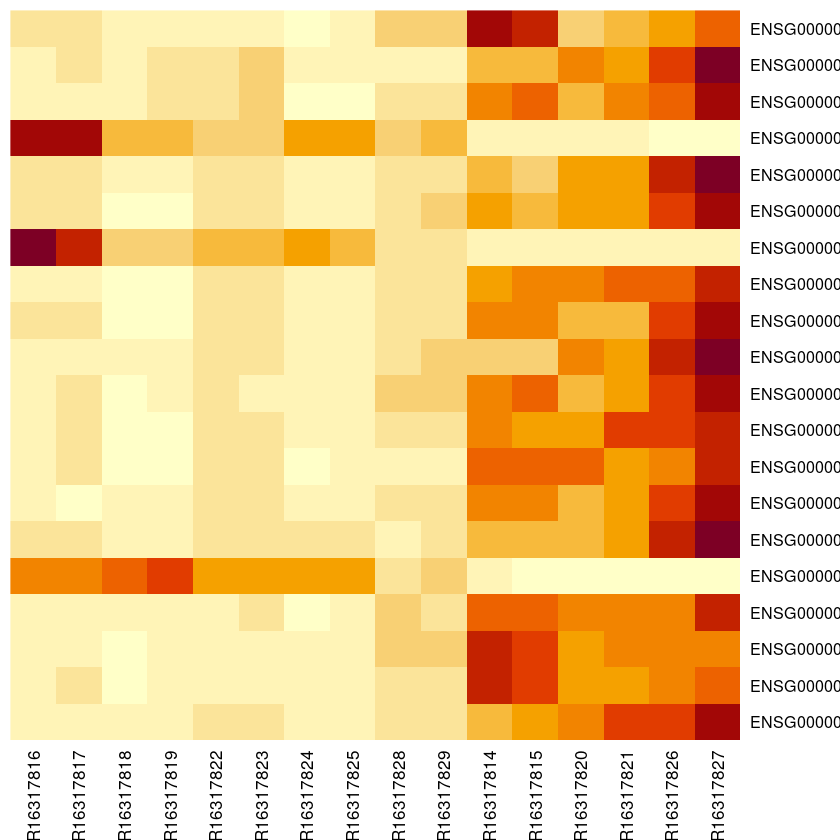

In [25]:
# Heatmap visualization of top 20 genes
heatmap(as.matrix(raw.cnts.top20), Colv=NA, Rowv=NA)

In [26]:
# Obtaining expression levels of top 50 genes from counts of interest
raw.cnts.top50 <- counts.of.interest[top50.genes, ]

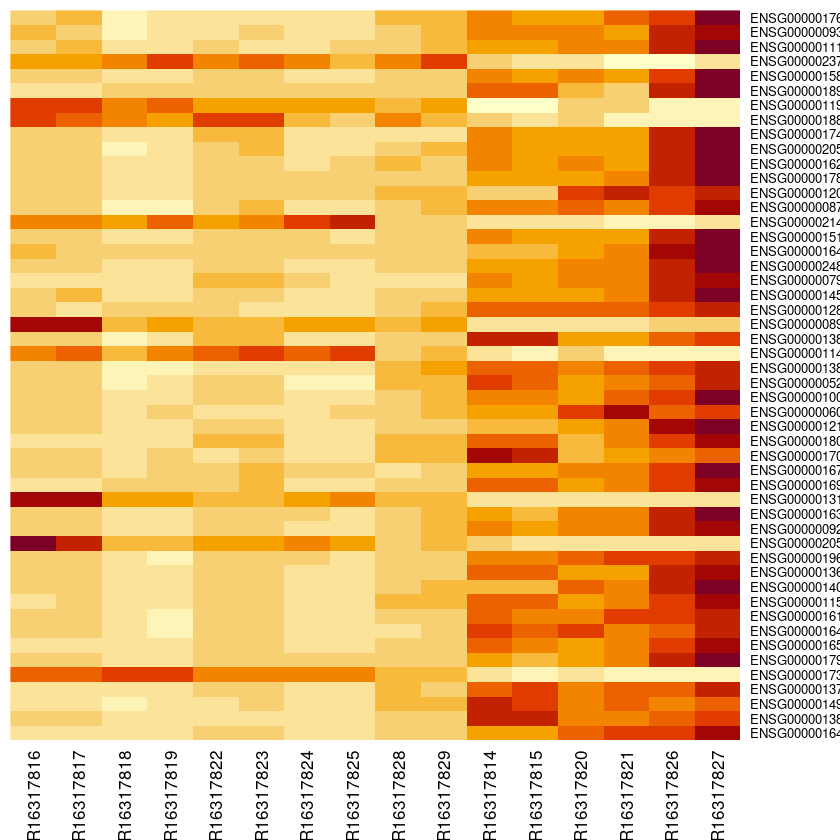

In [27]:
# Heatmap visualization of top 50 genes
heatmap(as.matrix(raw.cnts.top50), Colv=NA, Rowv=NA)

In [28]:
# Obtaining expression levels of top 100 genes from counts of interest
raw.cnts.top100 <- counts.of.interest[top100.genes, ]

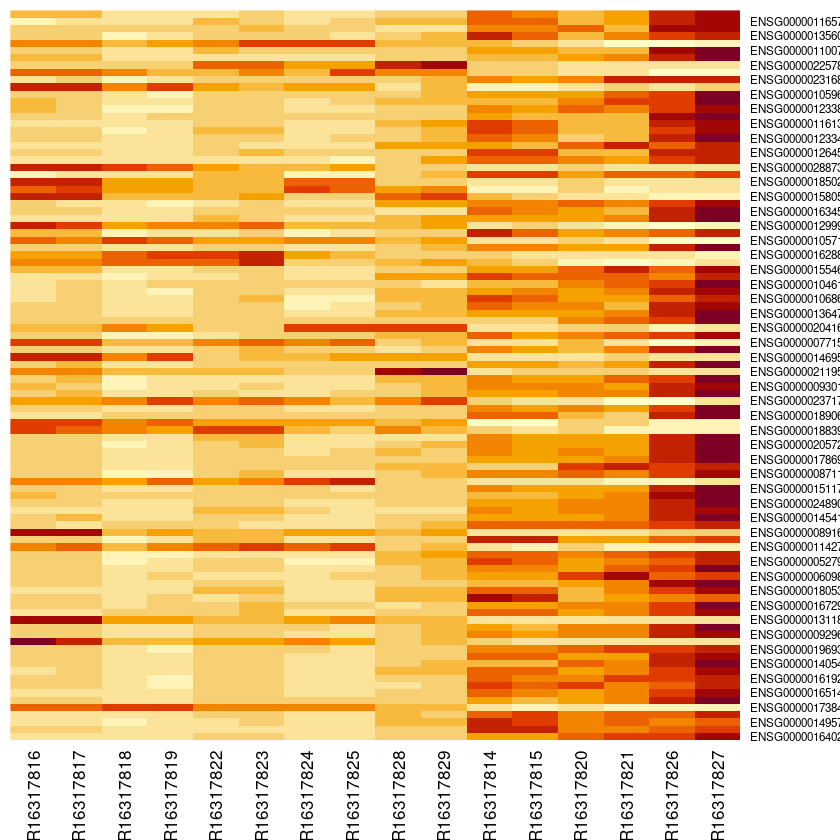

In [29]:
# Heatmap visualization of top 100 genes
heatmap(as.matrix(raw.cnts.top100), Colv=NA, Rowv=NA)

In [30]:
# Extracting the top differentially expressed genes
deg_results_HvsI <- topTags(et, n = Inf)$table
head(deg_results_HvsI)

,logFC,logCPM,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000164023,1.697797,4.773522,1.175926e-20,1.422047e-16
ENSG00000138439,1.533099,3.953398,1.104501e-19,6.678365e-16
ENSG00000149577,1.101860,5.913503,4.174449e-16,1.682720e-12
ENSG00000137962,1.306188,2.926750,2.945574e-15,8.905206e-12
ENSG00000173846,-1.870181,6.244295,4.700782e-14,1.136931e-10
ENSG00000179241,2.140453,3.934193,6.931970e-14,1.397138e-10


In [31]:
# # Ensure row names (gene IDs) are saved as a column
# deg_results_HvsI$GeneID <- rownames(deg_results_HvsI)

# # Save the file with GeneID included
# write.csv(deg_results_HvsI, file = file.path(getwd(), "deg_results_HvsI.csv"), row.names = FALSE)
